In [2]:
import polars as pl

In [ ]:
full_schema = {
    "original_line": pl.String,
    "title": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "primary_artist": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "secondary_artist": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
    "title_type": pl.Struct({
        "choice": pl.String,
        "confidence": pl.Float16,
    }),
}
stream_titles = pl.read_json("../test_outputs/parsed_titles.json",
                      schema=full_schema)
stream_titles = stream_titles.unnest('title', 'primary_artist', 'secondary_artist', 'title_type', separator='_')
stream_titles

original_line,title_choice,title_confidence,primary_artist_choice,primary_artist_confidence,secondary_artist_choice,secondary_artist_confidence,title_type_choice,title_type_confidence
str,str,f16,str,f16,str,f16,str,f16
"""Pritam, Darshan Raval and An…","""Mehrama""",1.0,"""Pritam, Darshan Raval and An…",0.5,"""none""",0.629883,"""track""",0.930176
"""Arijit Singh - Tujhe Kitna Cha…","""Tujhe Kitna Chahne Lage""",1.0,"""Arijit Singh""",1.0,"""none""",0.970215,"""track""",1.0
"""Vishal Bhardwaj, Arijit Singh …","""Hum To Tere Hi Liye The""",1.0,"""Vishal Bhardwaj, Arijit Singh …",0.609863,"""none""",0.609863,"""track""",0.97998
"""Vishal Mishra, Kaushik-Guddu …","""Deewaniyat""",0.990234,"""Vishal Mishra, Kaushik-Guddu …",0.830078,"""none""",0.660156,"""track""",0.959961
"""Alka Yagnik, Kumar Sanu - Mere…","""Mere Khabo Mein Tu""",1.0,"""Alka Yagnik, Kumar Sanu""",0.75,"""none""",0.399902,"""track""",0.990234
…,…,…,…,…,…,…,…,…
"""Shashwat Sachdev, Diljit Dosan…","""Ez-Ez""",0.990234,"""Shashwat Sachdev, Diljit Dosan…",0.580078,"""none""",0.509766,"""track""",0.939941
""" - I knew it, I knew you / Tay…","""I knew it, I knew you""",0.890137,"""Taylor Swift""",0.990234,"""none""",0.810059,"""track""",0.990234
""" - Tracklist: https://dancewav…","""none""",0.409912,"""none""",0.22998,"""none""",0.850098,"""track""",0.429932


In [42]:
stream_titles['title_type_choice'].value_counts()

title_type_choice,count
str,u32
"""commercial""",14
"""track""",460
"""content_segment""",244
"""radio_jingle""",21


In [81]:
res = stream_titles.group_by("title_type_choice").agg(
    q10=pl.col("title_confidence").quantile(0.15),
    q25=pl.col("title_confidence").quantile(0.25),
    q75=pl.col("title_confidence").quantile(0.75),
    median=pl.col("title_confidence").median()
)

print(res)

shape: (4, 5)
┌───────────────────┬──────────┬──────────┬──────────┬──────────┐
│ title_type_choice ┆ q10      ┆ q25      ┆ q75      ┆ median   │
│ ---               ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str               ┆ f16      ┆ f16      ┆ f16      ┆ f16      │
╞═══════════════════╪══════════╪══════════╪══════════╪══════════╡
│ content_segment   ┆ 0.059998 ┆ 0.090027 ┆ 0.759766 ┆ 0.360107 │
│ radio_jingle      ┆ 0.109985 ┆ 0.209961 ┆ 0.959961 ┆ 0.720215 │
│ track             ┆ 0.52002  ┆ 0.950195 ┆ 1.0      ┆ 0.990234 │
│ commercial        ┆ 0.27002  ┆ 0.540039 ┆ 0.870117 ┆ 0.794922 │
└───────────────────┴──────────┴──────────┴──────────┴──────────┘


<Axes: xlabel='title_type_choice', ylabel='title_type_confidence'>

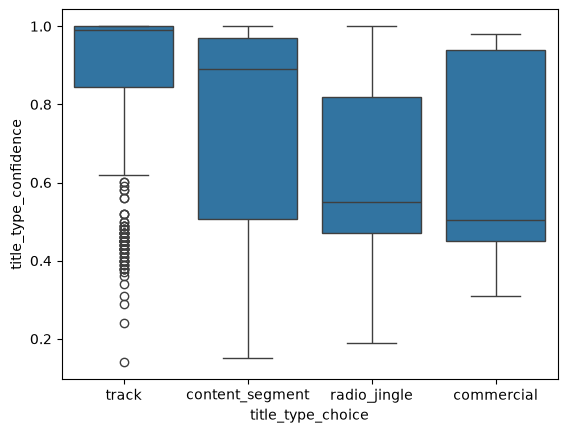

In [112]:
import seaborn as sns
sns.boxplot(data=stream_titles, x="title_type_choice", y="title_type_confidence")

In [61]:
only_tracks = stream_titles.filter(pl.col('title_type_choice') == 'track')

In [116]:
result = only_tracks.select(
    count_below_q1=(pl.col("title_type_confidence") < pl.col("title_confidence").quantile(0.1)).sum(),
    count_below_60=(pl.col("title_type_confidence") < 0.60).sum()
)
result, only_tracks.select(pl.col('title_choice').count()), result/only_tracks.select(pl.col('title_choice').count())

(shape: (1, 2)
 ┌────────────────┬────────────────┐
 │ count_below_q1 ┆ count_below_60 │
 │ ---            ┆ ---            │
 │ u32            ┆ u32            │
 ╞════════════════╪════════════════╡
 │ 36             ┆ 77             │
 └────────────────┴────────────────┘,
 shape: (1, 1)
 ┌──────────────┐
 │ title_choice │
 │ ---          │
 │ u32          │
 ╞══════════════╡
 │ 460          │
 └──────────────┘,
 shape: (1, 1)
 ┌────────────────┐
 │ count_below_q1 │
 │ ---            │
 │ f64            │
 ╞════════════════╡
 │ 0.078261       │
 └────────────────┘)

In [117]:
valid_titles = stream_titles.filter((pl.col('title_type_choice') == 'track') & (pl.col('title_type_confidence') >= 0.6))

In [118]:
valid_titles.select("title_choice", "primary_artist_choice", "secondary_artist_choice")

title_choice,primary_artist_choice,secondary_artist_choice
str,str,str
"""Mehrama""","""Pritam, Darshan Raval and An…","""none"""
"""Tujhe Kitna Chahne Lage""","""Arijit Singh""","""none"""
"""Hum To Tere Hi Liye The""","""Vishal Bhardwaj, Arijit Singh …","""none"""
"""Deewaniyat""","""Vishal Mishra, Kaushik-Guddu …","""none"""
"""Mere Khabo Mein Tu""","""Alka Yagnik, Kumar Sanu""","""none"""
…,…,…
"""Yeh Dooriyan""","""Pritam and Mohit Chauhan""","""none"""
"""Hands To Myself""","""Selena Gomez""","""none"""
"""Don""","""Swedish House Mafia feat. John…","""none"""


In [99]:
resolved = pl.read_csv('../musicbrainzngs_resolved_logs.csv')
resolved

input_artist,input_title,source,resolved_artist,resolved_title
str,str,str,str,str
"""Niall Horan""","""Heaven""","""musicbrainzngs""","""Niall Horan""","""Heaven"""
"""Ofenbach""","""Be mine""","""musicbrainzngs""","""Ofenbach""","""Be Mine"""
"""Milky""","""Just The Way You Are""","""musicbrainzngs""","""Milky""","""Just the Way You Are"""
"""Armaan Malik""","""Jab Tak""","""musicbrainzngs""","""Armaan Malik""","""Jab Tak"""
"""Taylor Swift""","""Blank Space""","""musicbrainzngs""","""Taylor Swift""","""Blank Space"""
…,…,…,…,…
"""Radio Caroline""","""www.radiocaroline.co.uk (16:43…","""musicbrainzngs""","""To Live and Shave in L.A.""","""1643"""
null,"""HUM BHUL GAYE RE""","""musicbrainzngs""","""Brian Silas""","""Mohe Bhul Gaye Sawaria (Aaja R…"
"""Whitney Houston""","""How Will I Know""","""musicbrainzngs""","""Walt Ribeiro""","""Whitney Houston ‘How Will I Kn…"


In [111]:
resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum()

input_title
u32
165


In [119]:
resolved.select((pl.col('input_title') == pl.col('resolved_title')) & (pl.col('input_artist') == pl.col('resolved_artist'))).sum()


input_title
u32
78


In [107]:
resolved.count()

input_artist,input_title,source,resolved_artist,resolved_title
u32,u32,u32,u32,u32
354,381,381,381,381


In [126]:
resolved_jev = pl.read_csv('../test_outputs/resolved_titles.csv')
resolved_jev

input_artist,input_title,source,resolved_artist,resolved_title
str,str,str,str,str
"""Pritam, Darshan Raval and An…","""Mehrama""","""musicbrainzngs""","""Darshan Raval""","""Mehrama"""
"""Arijit Singh""","""Tujhe Kitna Chahne Lage""","""musicbrainzngs""","""Arijit Singh""","""Tujhe Kitna Chahne Lage"""
"""Vishal Bhardwaj, Arijit Singh …","""Hum To Tere Hi Liye The""","""musicbrainzngs""","""Vishal Bhardwaj""","""Hum To Tere Hi Liye The (choir…"
"""Vishal Mishra, Kaushik-Guddu …","""Deewaniyat""","""musicbrainzngs""","""Vishal Mishra""","""Deewaniyat"""
"""Alka Yagnik, Kumar Sanu""","""Mere Khabo Mein Tu""","""musicbrainzngs""","""Kumar Sanu""","""Mere Khabo Mein Tu"""
…,…,…,…,…
"""Pritam and Mohit Chauhan""","""Yeh Dooriyan""","""musicbrainzngs""","""Mohit Chauhan""","""Yeh Dooriyan"""
"""Selena Gomez""","""Hands To Myself""","""musicbrainzngs""","""Selena Gomez""","""Hands to Myself"""
"""Swedish House Mafia feat. John…","""Don""","""musicbrainzngs""","""Swedish House Mafia""","""Don't You Worry Child"""


In [127]:
resolved_jev.select(pl.col('input_title') == pl.col('resolved_title')).sum()

input_title
u32
182


In [128]:
resolved_jev.select((pl.col('input_title') == pl.col('resolved_title')) & (pl.col('input_artist') == pl.col('resolved_artist'))).sum()

input_title
u32
80


In [140]:
(resolved_jev.select(pl.col('input_title') == pl.col('resolved_title')).sum() - resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum())/resolved.select(pl.col('input_title') == pl.col('resolved_title')).sum()
# so about a 10% improvement in parsing

input_title
f64
0.10303


In [ ]:
result = resolved.join(resolved_jev, on="input_title", how="outer")
result.columns

C:\Users\Vignesh\AppData\Local\Temp\ipykernel_33936\580497769.py:1: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  result = resolved.join(resolved_jev, on="input_title", how="outer")


['input_artist',
 'input_title',
 'source',
 'resolved_artist',
 'resolved_title',
 'input_artist_right',
 'input_title_right',
 'source_right',
 'resolved_artist_right',
 'resolved_title_right']

In [142]:
result.filter(
    (pl.col('input_title') == pl.col('resolved_title'))
    & (pl.col('input_title_right') != pl.col('resolved_title_right')))

input_artist,input_title,source,resolved_artist,resolved_title,input_artist_right,input_title_right,source_right,resolved_artist_right,resolved_title_right
str,str,str,str,str,str,str,str,str,str
"""Kelly Clarkson""","""Since U Been Gone""","""musicbrainzngs""","""Kelly Clarkson""","""Since U Been Gone""","""none""","""Since U Been Gone""","""musicbrainzngs""","""Addison Groove""","""U Been Gone"""
"""Ke$ha""","""Tik Tok""","""musicbrainzngs""","""Kesha""","""Tik Tok""","""none""","""Tik Tok""","""musicbrainzngs""","""Zombie Cats""","""Tik Tok Tik Tok"""
"""Tame Impala / Jennie""","""Dracula""","""musicbrainzngs""","""Tame Impala""","""Dracula""","""none""","""Dracula""","""musicbrainzngs""","""Philip Glass""","""Dracula: Dracula"""
"""Ke$ha""","""Tik Tok""","""musicbrainzngs""","""Kesha""","""Tik Tok""","""none""","""Tik Tok""","""musicbrainzngs""","""Zombie Cats""","""Tik Tok Tik Tok"""
"""Tame Impala / Jennie""","""Dracula""","""musicbrainzngs""","""Tame Impala""","""Dracula""","""none""","""Dracula""","""musicbrainzngs""","""Philip Glass""","""Dracula: Dracula"""
…,…,…,…,…,…,…,…,…,…
"""Sabrina Carpenter""","""Taste""","""musicbrainzngs""","""Sabrina Carpenter""","""Taste""","""none""","""Taste""","""musicbrainzngs""","""None""","""Day When I'll Know..."""
"""JA RULE / ASHANTI""","""Always On Time""","""musicbrainzngs""","""Ja Rule""","""Always On Time""","""JA RULE""","""Always On Time""","""musicbrainzngs""","""Ja Rule""","""Always on Time"""
"""SZA""","""Saturn""","""musicbrainzngs""","""SZA""","""Saturn""","""SZASZA""","""Saturn""","""musicbrainzngs""","""Szasza""","""Valami Rap"""


In [ ]:
// Doesn't immediately seem like a good option for separation of artist and titles.